In [116]:
import warnings
warnings.filterwarnings('ignore')

In [117]:
import pandas as pd
import seaborn as sns
from sklearn import tree
import matplotlib.pyplot as plt

df = pd.read_csv('445_CapstoneData.csv')
df.head()

,Sheet,VIN,Year,Make,Model,Days Stored,Order Date,Repo Date,Client Name,Lienholder Name,Release Date,Recovery Zip,Storage City,Storage State,Storage Zip,Forward vs Direct (1 is Dir),TenOrMore
0,2022,2GKALMEK1D6341938,2013.0,GMC,Terrain,10.0,2/16/21,7/13/22,PAR North America,America First FCU,7/22/22,15120.0,Pittsburgh,PA,15239.0,0,1
1,2022,KMHEC4A46CA045329,2012.0,HYUNDAI,SONATA,12.0,3/2/21,1/24/22,Carvant Financial LLC,Carvant Financial LLC,2/4/22,8081.0,CHESTER,PA,19013.0,1,1
2,2022,4T1BF3EK4AU082873,2010.0,Toyota,Camry,2.0,7/13/21,2/2/22,Ionadi Auto Sales,Ionadi Auto Sales,2/3/22,15206.0,Pittsburgh,PA,15239.0,1,0
3,2022,KMHDH4AE1CU311019,2012.0,HYUNDAI,ELANTRA,14.0,8/17/21,1/5/22,Secure Collateral Management Llc,Capital One Auto Finance,1/18/22,19139.0,CHESTER,PA,19013.0,0,1
4,2022,YH4K12AA8CA000406,2012.0,Fisker,Karma,12.0,8/26/21,8/22/22,Kinetic Advantage LLC,Kinetic Advantage LLC,9/2/22,19119.0,BENSALEM,PA,19020.0,1,1


In [118]:
df.shape

(59955, 17)

In [119]:
df.dropna(inplace=True)

In [120]:
df.isnull().sum()

Sheet                           0
VIN                             0
Year                            0
Make                            0
Model                           0
Days Stored                     0
Order Date                      0
Repo Date                       0
Client Name                     0
Lienholder Name                 0
Release Date                    0
Recovery Zip                    0
Storage City                    0
Storage State                   0
Storage Zip                     0
Forward vs Direct (1 is Dir)    0
TenOrMore                       0
dtype: int64

In [121]:
df.head()

,Sheet,VIN,Year,Make,Model,Days Stored,Order Date,Repo Date,Client Name,Lienholder Name,Release Date,Recovery Zip,Storage City,Storage State,Storage Zip,Forward vs Direct (1 is Dir),TenOrMore
0,2022,2GKALMEK1D6341938,2013.0,GMC,Terrain,10.0,2/16/21,7/13/22,PAR North America,America First FCU,7/22/22,15120.0,Pittsburgh,PA,15239.0,0,1
1,2022,KMHEC4A46CA045329,2012.0,HYUNDAI,SONATA,12.0,3/2/21,1/24/22,Carvant Financial LLC,Carvant Financial LLC,2/4/22,8081.0,CHESTER,PA,19013.0,1,1
2,2022,4T1BF3EK4AU082873,2010.0,Toyota,Camry,2.0,7/13/21,2/2/22,Ionadi Auto Sales,Ionadi Auto Sales,2/3/22,15206.0,Pittsburgh,PA,15239.0,1,0
3,2022,KMHDH4AE1CU311019,2012.0,HYUNDAI,ELANTRA,14.0,8/17/21,1/5/22,Secure Collateral Management Llc,Capital One Auto Finance,1/18/22,19139.0,CHESTER,PA,19013.0,0,1
4,2022,YH4K12AA8CA000406,2012.0,Fisker,Karma,12.0,8/26/21,8/22/22,Kinetic Advantage LLC,Kinetic Advantage LLC,9/2/22,19119.0,BENSALEM,PA,19020.0,1,1


In [122]:
freqtb=df['Forward vs Direct (1 is Dir)'].value_counts().reset_index()
freqtb.columns=['Forward vs Direct (1 is Dir)', 'Count']
print(freqtb)

   Forward vs Direct (1 is Dir)  Count
0                             0  44741
1                             1  14804


In [124]:
Y = df['TenOrMore']
X = df[['Forward vs Direct (1 is Dir)']]

In [125]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.3, random_state = 0) 

In [126]:
Y_train.value_counts(sort=False)

1    21810
0    19871
Name: TenOrMore, dtype: int64

In [127]:
Y_test.value_counts(sort=False)

0    8516
1    9348
Name: TenOrMore, dtype: int64

In [128]:
from sklearn import tree

clf= tree.DecisionTreeClassifier(max_depth=5, random_state = 0)
clf= clf.fit(X_train,Y_train)

[Text(0.5, 0.75, 'Forward vs Direct (1 is Dir) <= 0.5\ngini = 0.499\nsamples = 41681\nvalue = [19871, 21810]'),
 Text(0.25, 0.25, 'gini = 0.493\nsamples = 31233\nvalue = [13789, 17444]'),
 Text(0.75, 0.25, 'gini = 0.487\nsamples = 10448\nvalue = [6082, 4366]')]

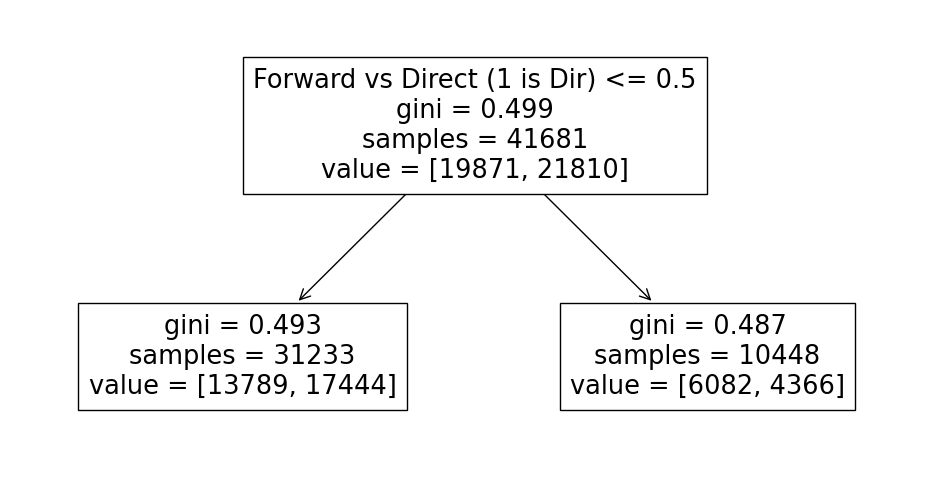

In [129]:
 plt.figure(figsize=(12,6))
tree.plot_tree(clf,feature_names=['Forward vs Direct (1 is Dir)'])

In [130]:
accuracy = clf.score(X_train,Y_train) 
print("Your decision tree is {:.2f}% accurate.".format(accuracy*100))

Your decision tree is 56.44% accurate.


In [131]:
from sklearn.metrics import confusion_matrix
predictions= clf.predict(X_train)
cm = confusion_matrix(Y_train, predictions)
cm

array([[ 6082, 13789],
       [ 4366, 17444]])

In [132]:
Y_train.value_counts(sort=False)

1    21810
0    19871
Name: TenOrMore, dtype: int64

In [133]:
clf.feature_importances_

array([1.])

In [ ]:
#Test Set

In [134]:
clf = tree.DecisionTreeClassifier(max_depth=5, random_state = 0)
clf = clf.fit(X_test,Y_test)

[Text(0.5, 0.75, 'Forward vs Direct (1 is Dir) <= 0.5\ngini = 0.499\nsamples = 17864\nvalue = [8516, 9348]'),
 Text(0.25, 0.25, 'gini = 0.493\nsamples = 13508\nvalue = [5962, 7546]'),
 Text(0.75, 0.25, 'gini = 0.485\nsamples = 4356\nvalue = [2554, 1802]')]

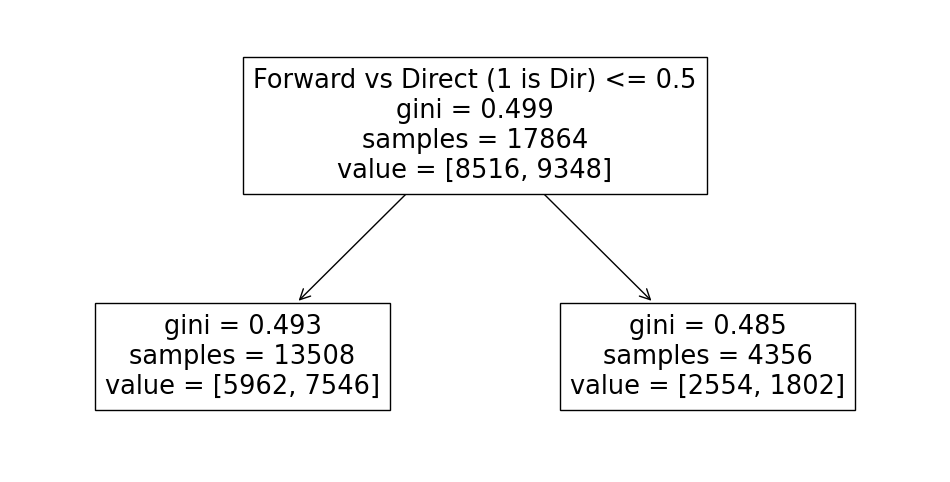

In [135]:
plt.figure(figsize=(12,6))
tree.plot_tree(clf,feature_names=['Forward vs Direct (1 is Dir)'])

In [136]:
accuracy = clf.score(X_test,Y_test) 
print("Your decision tree is {:.2f}% accurate.".format(accuracy*100))

Your decision tree is 56.54% accurate.
